# Actividad: Redes aleatorias vs redes reales

¿Se puede usar el modelo para intentar describir la estructura y comportamiento de las redes reales? 

Van a realizar la siguiente actividad para la mini-red y una red real.

1. Cargar los datos y crear la red:

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.io as pio
from pathlib import Path
import seaborn as sns
sns.set_style('whitegrid')

pio.renderers.default = "vscode"
plt.set_cmap("rainbow")

<Figure size 640x480 with 0 Axes>

In [2]:
folder = Path("data/dataverse/gexf")
movie_id = 774
fp = folder / f"{movie_id}.gexf"

G = nx.read_gexf(fp, node_type=int)
print("loaded", movie_id, "| Nodos:", G.number_of_nodes(),
      "| Aristas:", G.number_of_edges())

loaded 774 | Nodos: 47 | Aristas: 148


In [3]:
def relabel_nodes_from_attr(
    G: nx.Graph,
    *,
    attr: str = "label",
    fallback_to_id: bool = True,
    make_unique: bool = True,
    copy: bool = True,
) -> nx.Graph:
    """
    Renombra nodos usando G.nodes[n][attr] (p.ej. 'label').
    - make_unique=True agrega sufijos ' (#2)' si hay nombres repetidos.
    """
    base_names = {}
    for n, d in G.nodes(data=True):
        name = d.get(attr)
        if name in (None, "") and fallback_to_id:
            name = str(n)
        base_names[n] = str(name)

    if make_unique:
        counts = {}
        mapping = {}
        for n, nm in base_names.items():
            k = counts.get(nm, 0) + 1
            counts[nm] = k
            mapping[n] = nm if k == 1 else f"{nm} (#{k})"
    else:
        mapping = base_names

    return nx.relabel_nodes(G, mapping, copy=copy)


G1 = relabel_nodes_from_attr(G, attr="label", make_unique=True, copy=True)

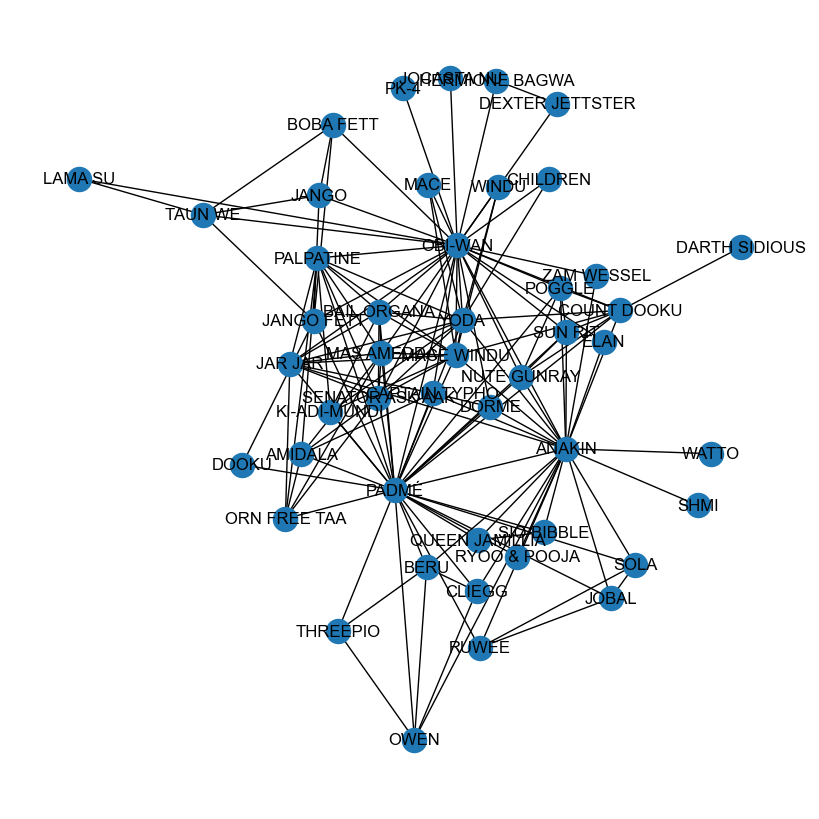

In [4]:
plt.figure(figsize=[8, 8])
layout = nx.kamada_kawai_layout(G1)
nx.draw(G1, layout, with_labels=True)

# Propiedades de la red

2. Una vez que se creó la red, determina $n$ la cantidad de nodos, $m$ el número de aristas, $\langle k\rangle$ el grado promedio y $C_{WS}$ el coeficiente de agrupamiento promedio.

In [5]:
n = len(G)
m = len(G.edges)
k = 2*m/n
C = nx.average_clustering(G)

print('Propiedades generales de la red:')
print('- El número de nodos es:\t', n)
print('- El número de aristas es:\t', m)
print('- El grado promedio es:\t\t', k)
print('- El coeficiente de agrupamiento promedio es:\n', C)

Propiedades generales de la red:
- El número de nodos es:	 47
- El número de aristas es:	 148
- El grado promedio es:		 6.297872340425532
- El coeficiente de agrupamiento promedio es:
 0.7513874803198227


## Coeficiente de agrupamiento aleatorio

3. Para compararla con una red aleatoria, hay que determinar $p$, la probabilidad de enlace que le correspondería si fuera una red aleatoria, la cual veremos en clase; o bien, es uno de los spoilers en este notebook. Supongo que es esto:

Como sabemos de la notebook pasada:

$$
\mathbb{E}[m]=p\binom{n}{2}=p\frac{n(n-1)}{2}.
$$

$$
\mathbb{E}[\langle k\rangle] = p(n-1).
$$


Despejando para $\hat{p}$

$$
\hat{p}= \frac{2m}{n(n-1)}.
$$

$$
\hat{p}=\frac{k}{n-1}
$$


Se van a calcular las propiedades que tiene la red aleatoria $G(n,p)$ con el mismo número de nodos y el mismo grado promedio que la red real para compararlas con las propiedades de la red real y ver si el modelo de red aleatoria se ajusta a la red real.

In [6]:
p1 = (2*m)/(n*(n-1))
p2 = k/(n-1)

print('\nEl coeficiente de agrupamiento que tendría la red si fuera aleatoria (es decir p) es:\n', p1)
print('El coeficiente de agrupamiento que tendría la red si fuera aleatoria (es decir p) es:\n', p2)


El coeficiente de agrupamiento que tendría la red si fuera aleatoria (es decir p) es:
 0.13691026827012026
El coeficiente de agrupamiento que tendría la red si fuera aleatoria (es decir p) es:
 0.13691026827012026


In [7]:
p = p1

## Comparacion

4. Al comparar los coeficientes de agrupamiento promedio, ¿consideras que el modelo de red aleatoria se ajusta a tu red?

No. Se comprueba con una prueba Monte Carlo

In [8]:
#Calcula lo siguiente

print('Propiedades generales de la red:')
print('- El número de nodos es:\t', n)
print('- El número de aristas es:\t', m)
print('- El grado promedio es:\t\t', k)
print('\n\nEl coeficiente de agrupamiento promedio de la red es:\n', C)
print('\nEl coeficiente de agrupamiento que tendría la red si fuera aleatoria (es decir p) es:\n', p)

Propiedades generales de la red:
- El número de nodos es:	 47
- El número de aristas es:	 148
- El grado promedio es:		 6.297872340425532


El coeficiente de agrupamiento promedio de la red es:
 0.7513874803198227

El coeficiente de agrupamiento que tendría la red si fuera aleatoria (es decir p) es:
 0.13691026827012026


In [9]:
# H0: la red real podria venir de una red aleatoria de Erdos-Renyi con estos n y p.

n_sim = 1000

C_sim = np.empty(n_sim)
for i in range(n_sim):
    G_sim = nx.erdos_renyi_graph(n, p)
    C_sim[i] = nx.average_clustering(G_sim)

centro_nulo = C_sim.mean()
dist_obs = abs(C - centro_nulo)
dist_sim = abs(C_sim - centro_nulo)

# p-valor bilateral con correccion +1 para evitar cero exacto por simulacion finita
p_valor_clustering = (np.sum(dist_sim >= dist_obs) + 1) / (n_sim + 1)

print(f"Promedio de <C> bajo G(n,p): {centro_nulo:.6f}")
print(f"<C> observado en la red real: {C:.6f}")
print(f"Diferencia observada: {C - centro_nulo:.6f}")
print(f"p-valor Monte Carlo (bilateral) = {p_valor_clustering:.6f}")

if p_valor_clustering < 0.05:
    print("\nConclusion: el coeficiente de agrupamiento promedio observado es estadisticamente distinto del esperado bajo una red aleatoria G(n,p).")
else:
    print("\nConclusion: no hay evidencia suficiente para decir que el coeficiente de agrupamiento promedio difiere del esperado bajo una red aleatoria G(n,p).")


Promedio de <C> bajo G(n,p): 0.134853
<C> observado en la red real: 0.751387
Diferencia observada: 0.616534
p-valor Monte Carlo (bilateral) = 0.000999

Conclusion: el coeficiente de agrupamiento promedio observado es estadisticamente distinto del esperado bajo una red aleatoria G(n,p).


# Distribución de grado

5. Realiza una tabla con el grado y el coeficiente de agrupamiento de cada nodo. Puedes usar diccionarios para crear un DataFrame con pandas con los siguientes pasos.

In [10]:
# se generan los diccionarios
grado_dict = dict(nx.degree(G))
clustering_dict = nx.clustering(G)

In [11]:
# se genera la tabla
df = pd.DataFrame([grado_dict, clustering_dict]).T
df.columns = ['Degree', 'Clustering']
df

,Degree,Clustering
4758954,6.0,0.733333
4759338,24.0,0.181159
4759235,9.0,0.888889
4762737,5.0,0.800000
4762367,4.0,1.000000
4758962,6.0,0.666667
4761481,2.0,1.000000
4762750,4.0,1.000000
4763601,9.0,0.611111
4764335,1.0,0.000000


C:\Users\herie\AppData\Local\Temp\ipykernel_31156\220529364.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


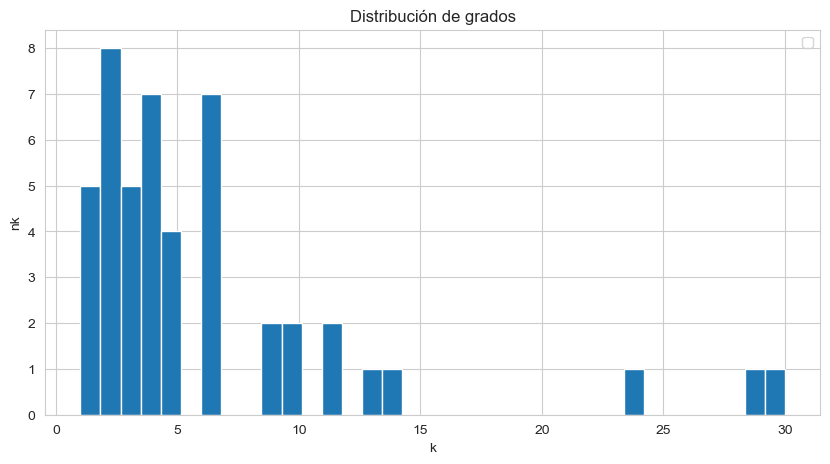

In [12]:

plt.figure(figsize = [10,5])
plt.hist(df['Degree'], bins=35)
plt.xlabel('k', size = 10)
plt.ylabel('nk', size = 10)
plt.title(f'Distribución de grados')
plt.legend()

## Histograma

6. Realiza y grafica el histograma de distribución de grados junto con la distribución de Poisson que corresponedría al valor $p$ asociado, la cual sería la distribución de probabilidad esperada si la red fuera una red aleatoria.

In [13]:
from scipy.stats import poisson, Binomial

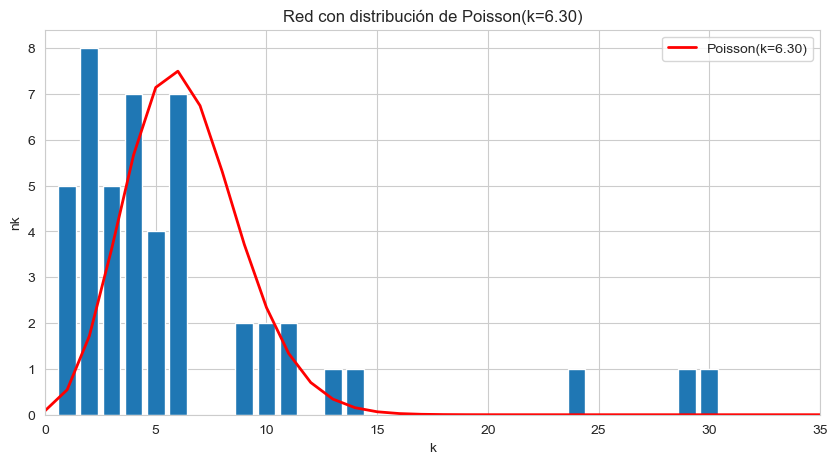

In [14]:
y, x= np.histogram([dict(G.degree)[i] for i in G],bins = range(n))

plt.figure(figsize = [10,5])
plt.plot(x[:-1],poisson.pmf(x[:-1],k)*n, label = f'Poisson(k={k:.2f})', color = 'red', linewidth=2)
plt.bar(x[:-1],y, alpha=1)
plt.xlabel('k', size = 10)
plt.ylabel('nk', size = 10)
plt.title(f'Red con distribución de Poisson(k={k:.2f})')
plt.xlim(0, 35)
plt.legend()

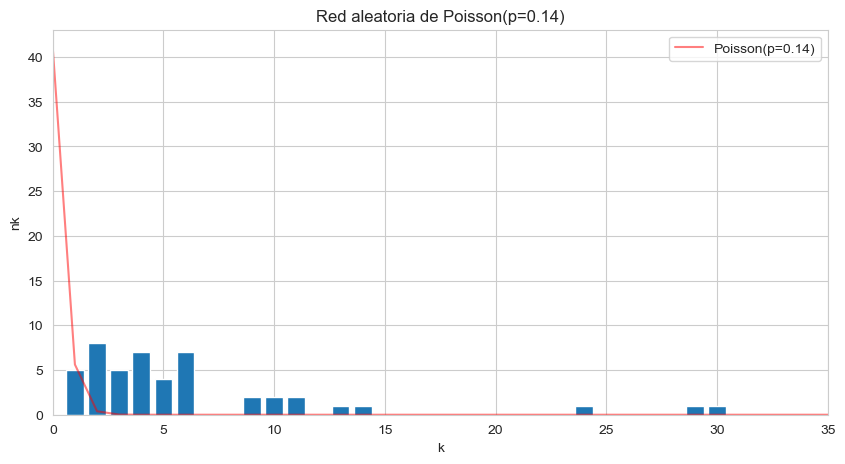

In [15]:
y, x= np.histogram([dict(G.degree)[i] for i in G],bins = range(n))

plt.figure(figsize = [10,5])
plt.plot(x[:-1],poisson.pmf(x[:-1],p)*n, label = f'Poisson(p={p:.2f})', color = 'red', alpha=0.5)
plt.bar(x[:-1],y)
plt.xlabel('k', size = 10)
plt.ylabel('nk', size = 10)
plt.title(f'Red aleatoria de Poisson(p={p:.2f})')
plt.xlim(0, 35)
plt.legend()

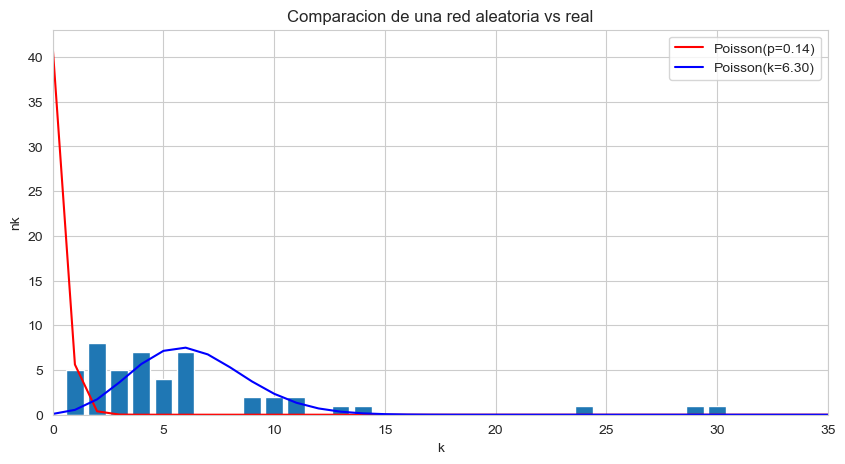

In [16]:
y, x= np.histogram([dict(G.degree)[i] for i in G],bins = range(n))

plt.figure(figsize = [10,5])
plt.plot(x[:-1],poisson.pmf(x[:-1],p)*n, label = f'Poisson(p={p:.2f})', color = 'red')
plt.plot(x[:-1],poisson.pmf(x[:-1],k)*n, label = f'Poisson(k={k:.2f})', color = 'blue')
plt.bar(x[:-1],y)
plt.xlabel('k', size = 10)
plt.ylabel('nk', size = 10)
plt.title(f'Comparacion de una red aleatoria vs real')
plt.xlim(0, 35)
plt.legend()

7. ¿Consideras que la distribución de grado de la red aleatoria correspondiente se ajusta a la distribución de grado de la red real que estás analizando?

No. Tambien se compara para saber si la red viene de una $\text{Poisson}(k)$, donde $k$ es el promedio de los grados.

In [17]:
from  scipy.stats import chi2

In [18]:
grados = df["Degree"].astype(int).to_numpy()
N = len(grados)
lam = grados.mean()
K = int(grados.max())

obs = np.array([(grados == i).sum() for i in range(K)])
obs = np.append(obs, (grados >= K).sum())

esp = np.array([N * poisson.pmf(i, lam) for i in range(K)])
esp = np.append(esp, N * (1 - poisson.cdf(K - 1, lam)))

# combinar clases con frecuencia esperada < 5
obs2 = obs.astype(float).copy()
esp2 = esp.astype(float).copy()

i = len(esp2) - 1
while i > 0:
    if esp2[i] < 5:
        esp2[i - 1] += esp2[i]
        obs2[i - 1] += obs2[i]
        esp2 = np.delete(esp2, i)
        obs2 = np.delete(obs2, i)
    i -= 1

chi2_stat = ((obs2 - esp2) ** 2 / esp2).sum()
gl = len(obs2) - 2   # clases finales - 1 - 1 parámetro estimado

p_valor = 1 - chi2.cdf(chi2_stat, df=gl)

print(f"Chi-cuadrada = {chi2_stat:.4f}")
print(f"Grados de libertad = {gl}")
print(f"p-valor = {p_valor:.6f}")

if p_valor < 0.05:
    print(f"\nConclusión: se rechaza H0 con p-valor = {p_valor:.6f}")
    print(f"La distribución de grado de la red real NO se ajusta a una Poisson({lam:.2f}).")
else:
    print(f"\nConclusión: no se rechaza H0 con p-valor = {p_valor:.6f}")
    print(f"La distribución de grado de la red real SÍ es compatible con una Poisson({lam:.2f}).")


Chi-cuadrada = 55.7357
Grados de libertad = 6
p-valor = 0.000000

Conclusión: se rechaza H0 con p-valor = 0.000000
La distribución de grado de la red real NO se ajusta a una Poisson(6.30).


## Lognormal

Creo que es lognormal, tiene la cara. Tiene cola derecha pesada, y podemos pensar que el cambio de un colaborador o colaborar con otro sigue un cambio en escala logaritica o algo asi

In [19]:
from scipy.stats import lognorm

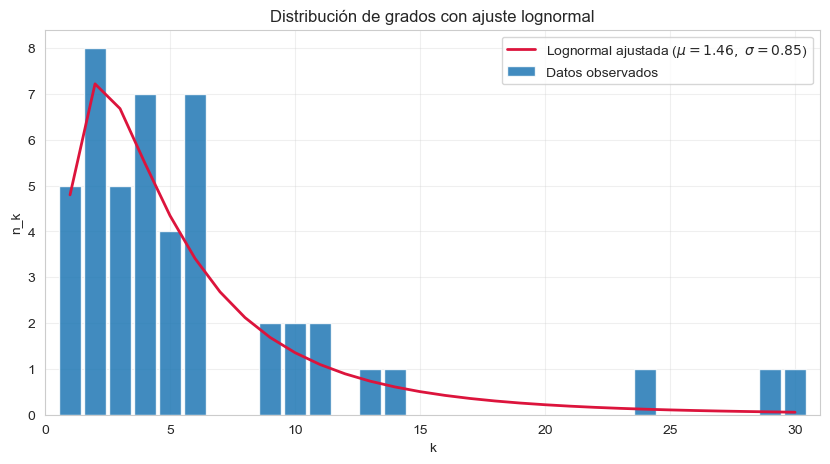

In [20]:
# Grados de la red
degrees_all = np.array([d for _, d in G.degree()])

# La lognormal solo tiene soporte en k > 0
degrees = degrees_all[degrees_all > 0]

if len(degrees) < len(degrees_all):
    print(f"Se excluyeron {len(degrees_all) - len(degrees)} nodos con k=0 "
          "porque la lognormal solo está definida para k > 0.")

n = len(degrees)
kmax = degrees.max()

# Ajuste por máxima verosimilitud con loc=0
sigma, loc, scale = lognorm.fit(degrees, floc=0)
mu = np.log(scale)

dist = lognorm(s=sigma, loc=0, scale=scale)

# Histograma discreto por grado entero
k_vals = np.arange(1, kmax + 1)
bin_edges = np.arange(0.5, kmax + 1.5, 1)
obs, _ = np.histogram(degrees, bins=bin_edges)

# Frecuencias esperadas por grado entero
expected = n * (dist.cdf(k_vals + 0.5) - dist.cdf(k_vals - 0.5))

plt.figure(figsize=(10, 5))
plt.bar(k_vals, obs, width=0.9, alpha=0.85, label='Datos observados')
plt.plot(
    k_vals,
    expected,
    color='crimson',
    linewidth=2,
    label=fr'Lognormal ajustada ($\mu={mu:.2f},\ \sigma={sigma:.2f}$)'
)

plt.xlabel('k')
plt.ylabel('n_k')
plt.title('Distribución de grados con ajuste lognormal')
plt.xlim(0, min(35, kmax + 1))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [21]:
# ---------- Bondad de ajuste: chi-cuadrado ----------

# Para que toda la masa quede incluida, hacemos categorías:
# 1, 2, ..., kmax-1, >= kmax
edges_chi = np.r_[0.5, np.arange(1.5, kmax + 0.5, 1), np.inf]
obs_chi, _ = np.histogram(degrees, bins=edges_chi)

exp_chi = []
for i in range(len(edges_chi) - 1):
    a, b = edges_chi[i], edges_chi[i + 1]
    Fa = dist.cdf(a)
    Fb = dist.cdf(b) if np.isfinite(b) else 1.0
    exp_chi.append(n * (Fb - Fa))
exp_chi = np.array(exp_chi)

def agrupar_bins(obs, exp, min_exp=5):
    obs_g, exp_g = [], []
    o_acc, e_acc = 0.0, 0.0

    for o, e in zip(obs, exp):
        o_acc += o
        e_acc += e
        if e_acc >= min_exp:
            obs_g.append(o_acc)
            exp_g.append(e_acc)
            o_acc, e_acc = 0.0, 0.0

    # si queda un residuo, se fusiona con el último grupo
    if e_acc > 0:
        if len(exp_g) == 0:
            obs_g.append(o_acc)
            exp_g.append(e_acc)
        else:
            obs_g[-1] += o_acc
            exp_g[-1] += e_acc

    return np.array(obs_g), np.array(exp_g)

obs_g, exp_g = agrupar_bins(obs_chi, exp_chi, min_exp=5)

chi2_stat = np.sum((obs_g - exp_g)**2 / exp_g)

# gl = número de grupos - 1 - número de parámetros estimados (mu, sigma)
gl = len(obs_g) - 1 - 2

print(f"mu = {mu:.4f}")
print(f"sigma = {sigma:.4f}")
print(f"Número de grupos tras agrupar = {len(obs_g)}")

if gl <= 0:
    print("No hay suficientes grupos con frecuencia esperada >= 5 para aplicar chi-cuadrado.")
else:
    p_val = chi2.sf(chi2_stat, df=gl)

    print(f"Chi-cuadrado = {chi2_stat:.4f}")
    print(f"gl = {gl}")
    print(f"p-valor = {p_val:.6g}")

    alpha = 0.05
    if p_val < alpha:
        print("Conclusión: se rechaza H0; la lognormal no ajusta bien la distribución de grados.")
    else:
        print("Conclusión: no se rechaza H0; la lognormal es compatible con la distribución de grados.")

mu = 1.4610
sigma = 0.8524
Número de grupos tras agrupar = 6
Chi-cuadrado = 5.4431
gl = 3
p-valor = 0.142084
Conclusión: no se rechaza H0; la lognormal es compatible con la distribución de grados.


:(

# Coeficiente de agrupamiento de los nodos

Usaremos tres representaciones para comparar los coeficientes de agrupamiento de los nodos de la red real con la red aleatorai equivalente. Ya vimos empíricamente (y veremos en clase) que el coeficiente en una red aleatoria es igual a la probabilidad $p$.

*Si dos nodos son vecinos de un mismo nodo, la probabilidad de que también estén conectados entre sí sigue siendo $p$, ya que las aristas se generan de manera independiente, los triángulos aparecen solo con la frecuencia esperada por azar. Entonces es $C_{WS} = p$*

## Primera representación

8. Grafica el coeficiente de agrupamiento de los nodos ordenándolos según su etiqueta. Utiliza la columna "Clustering" de la tabla creada anteriormente. En la misma gráfica muestra el valor que predice el modelo de red aleatoria $\left<C'\right> = p$ y el valor de $\left<C\right>$ empírico.

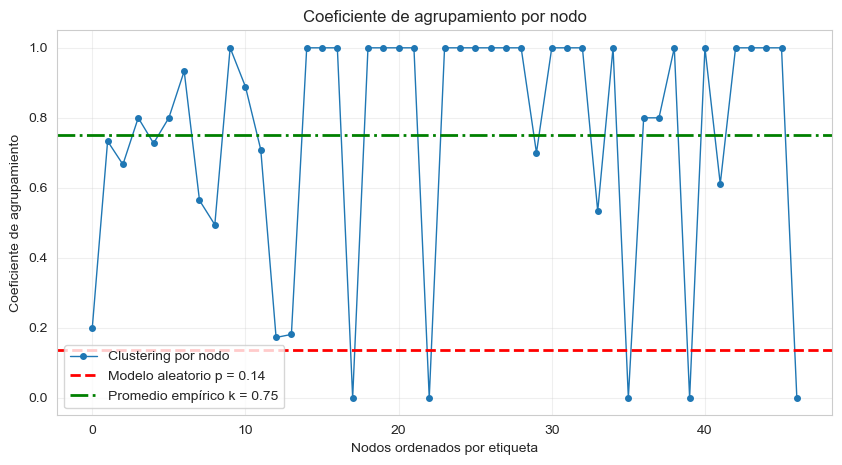

In [22]:
df_ordenado = df.sort_index()
clustering_vals = df_ordenado["Clustering"].to_numpy()
C_emp = clustering_vals.mean()
x = np.arange(len(clustering_vals))

plt.figure(figsize=(10, 5))
plt.plot(x, clustering_vals, 'o-', ms=4, lw=1, label='Clustering por nodo')
plt.axhline(p, color='red', linestyle='--', linewidth=2, label=f"Modelo aleatorio p = {p:.2f}")
plt.axhline(C_emp, color='green', linestyle='-.', linewidth=2, label=f"Promedio empírico k = {C_emp:.2f}")

plt.xlabel(f"Nodos ordenados por etiqueta")
plt.ylabel(f"Coeficiente de agrupamiento")
plt.title(f"Coeficiente de agrupamiento por nodo")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

9. ¿El coeficiente de agrupamiento que el modelo predice para cada nodo, se ajusta al coeficiente de agrupamiento de los nodos de tu red?

No, significa que la red no es aleatoria.

## Segunda representación

10. Grafica el coeficiente de agrupamiento de los nodos ordenándolos según su grado. Puedes utilizar y ordenar la columna "Degree" de la tabla creada anteriormente. En la misma gráfica muestra el valor que predice el modelo de red aleatoria  ⟨𝐶′⟩=𝑝 y el valor de  ⟨𝐶⟩  empírico.

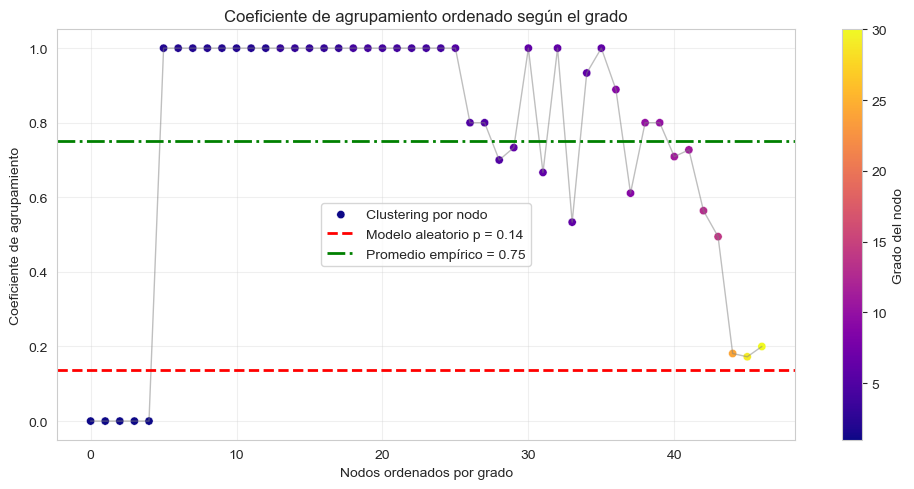

In [23]:
df_ordenado_grado = df.sort_values("Degree")
clustering_vals = df_ordenado_grado["Clustering"].to_numpy()
degree_vals = df_ordenado_grado["Degree"].to_numpy()

C_emp = clustering_vals.mean()
x = np.arange(len(clustering_vals))

plt.figure(figsize=(10, 5))

# linea para conectar los puntos
plt.plot(x, clustering_vals, '-', lw=1, color='gray', alpha=0.5)

# puntos coloreados por grado
sc = plt.scatter(
    x,
    clustering_vals,
    c=degree_vals,
    cmap="plasma",
    s=35,
    edgecolor="w",
    linewidth=0.3,
    label="Clustering por nodo"
)

plt.axhline(p, color='red', linestyle='--', linewidth=2,
            label=f"Modelo aleatorio p = {p:.2f}")
plt.axhline(C_emp, color='green', linestyle='-.', linewidth=2,
            label=f"Promedio empírico = {C_emp:.2f}")

plt.xlabel("Nodos ordenados por grado")
plt.ylabel("Coeficiente de agrupamiento")
plt.title("Coeficiente de agrupamiento ordenado según el grado")
plt.grid(alpha=0.3)
plt.legend()

cbar = plt.colorbar(sc)
cbar.set_label("Grado del nodo")

plt.tight_layout()
plt.show()

11. ¿Consideras que hay alguna correlación o patrón interesante entre el grado y el coeficiente de agrupamiento de los nodos?

Esta chistoso que el comportamiento es que los que tienen mayor y menor grado por nodo son los que tienen un coeficiente de agrupamiento mas bajo. Igual que en la red anterior, es porque los que tienen grado mas grande se conectan con unos nodos solitarios :p

Tambien, aqui esta interesante ver la correlacion, se hace una figura muy bonita en el scatter plot, porque mientras mas grande sea el grado menor es el coeficiente de agrupamiento, y justo en los que tienen el menor grado, son los que tienen el menor coeficiente de agrupamiento. Como que se contagia el coeficiente de agrupamiento por ellos.

In [24]:
from scipy.stats import spearmanr

In [25]:
x = df["Degree"].astype(float)
y = df["Clustering"].astype(float)

rho, p_valor = spearmanr(x, y)

print(f"Coeficiente de Spearman (rho) = {rho:.4f}")
print(f"p-valor = {p_valor:.6f}")

if p_valor < 0.05:
    if rho > 0:
        print("\nConclusión: hay una correlación positiva significativa entre k y C(k).")
    else:
        print("\nConclusión: hay una correlación negativa significativa entre k y C(k).")
else:
    print("\nConclusión: no hay evidencia estadísticamente significativa de correlación entre k y C(k).")


Coeficiente de Spearman (rho) = -0.2575
p-valor = 0.080527

Conclusión: no hay evidencia estadísticamente significativa de correlación entre k y C(k).


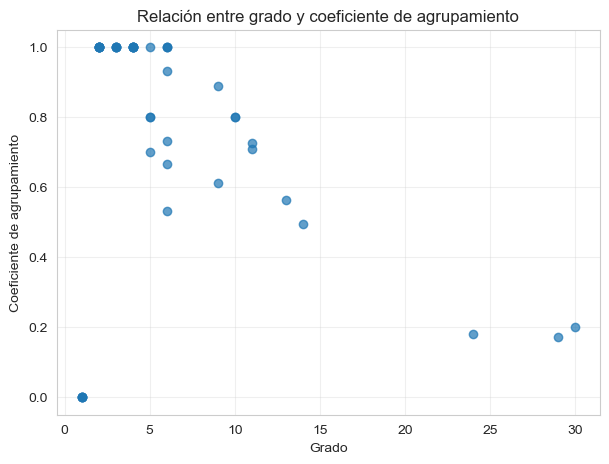

In [26]:

plt.figure(figsize=(7,5))
plt.scatter(x, y, alpha=0.7)
plt.xlabel("Grado")
plt.ylabel("Coeficiente de agrupamiento")
plt.title("Relación entre grado y coeficiente de agrupamiento")
plt.grid(alpha=0.3)
plt.show()


## Tercera representación.

11. Realiza una gráfica del coeficiente de agrupamiento promedio de los nodos, agrupados según se grado:

- Agrupa los elementos de la tabla según su valor de grado (puedes usar la función .groupby de pandas)
- De la tabla agrupada, considera solamente la columna "Clustering"
- De la propiead "Clustering" de los datos ya agrupados, calcula el promedio (puedes usar la función .mean())
- Forman los arreglos correspondientes al grado y al promedio del coeficiente de agrupamiento, puedes aplicar tres funciones seguidas: .reset_index().values.T
- Realiza la gráfica del coeficiente de agrupamiento promedio del grupo de nodos con grado $k$, denotado por $C(k)$. Indica los valores del promedio empírico y del predicho por el modelo de red aleatoria para obtener conclusiones.

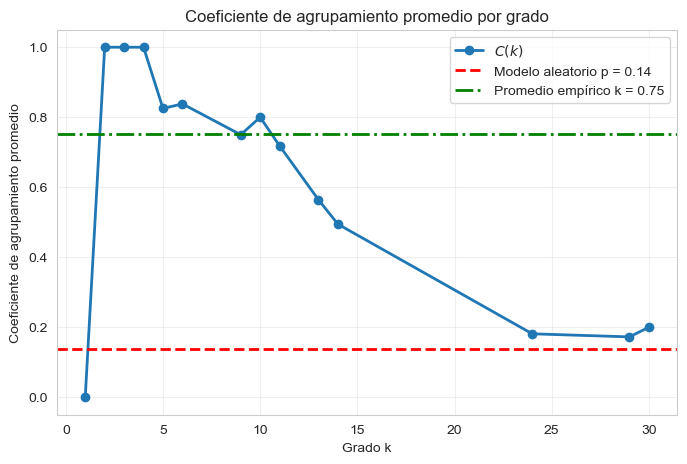

In [27]:
ck_df = df.groupby("Degree")["Clustering"].mean() # agrupar por grado y calcular el promedio de clustering
grado, Ck = ck_df.reset_index().values.T # formar los arreglos grado y C(k)
C_emp = df["Clustering"].mean() # promedio global

plt.figure(figsize=(8,5))
plt.plot(grado, Ck, 'o-', linewidth=2, label=r"$C(k)$")
plt.axhline(p, color='red', linestyle='--', linewidth=2, label=f"Modelo aleatorio p = {p:.2f}")
plt.axhline(C_emp, color='green', linestyle='-.', linewidth=2, label=f"Promedio empírico k = {C_emp:.2f}")

plt.xlabel("Grado k")
plt.ylabel(r"Coeficiente de agrupamiento promedio")
plt.title(r"Coeficiente de agrupamiento promedio por grado")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


12. En esta representación, ¿encuentras alguna correlación o patrón interesante entre los valores de  $k$ y  $C(k)$ ?

In [28]:
rho, p_valor = spearmanr(grado, Ck)

print(f"Coeficiente de Spearman (rho) = {rho:.4f}")
print(f"p-valor = {p_valor:.6f}")

if p_valor < 0.05:
    if rho > 0:
        print("\nConclusión: hay una correlación positiva significativa entre k y C(k).")
    else:
        print("\nConclusión: hay una correlación negativa significativa entre k y C(k).")
else:
    print("\nConclusión: no hay evidencia estadísticamente significativa de correlación entre k y C(k).")


Coeficiente de Spearman (rho) = -0.5717
p-valor = 0.032667

Conclusión: hay una correlación negativa significativa entre k y C(k).


Pasa lo mismo que con las coautorias, los personajes con pocas coaparicienes suelen pertenecer a vecindarios pequeños y muy cerrados, donde todos coaparecen con todos ,si aparecen pocas vecess. Los personajes con mas coapariciones tienen un gradeo de agrupamiento menor, porque aparecen con personajes que solo aparecen con ellos, y viceversa. 